# Willowbend Creek: Coupled 2D Nutrient Simulation

This notebook reproduces the model-output figures from the ClearWater-Riverine Nutrients technical report. It couples the ClearWater-Riverine 2D transport model with the Temperature Simulation Module (TSM) and the Nutrient Simulation Module (NSM1) on the synthetic Willowbend Creek test case.

Three boundaries drive the domain: a steady upstream inflow, a cool spring-fed tributary on the inside of the meander bend, and a powerplant discharge into the slow-flowing oxbow. The 24-hour simulation covers 2022-05-13 08:00 to 2022-05-14 08:00 UTC at a 30-second time step.

Inputs and a precomputed simulation output are bundled under `docs/examples/data/willowbend_creek/`. The notebook loads the precomputed coupled simulation output (`nsm1_output.zarr`) and produces the spatial and time-series figures from the report.


## 1. Imports and paths

Run this notebook from the documentation repository root. The relative path `docs/examples/data/willowbend_creek/` must resolve to the bundled test-case directory, which contains the precomputed NSM1 simulation output.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import xarray as xr

from _willowbend_nutrients_helpers import (
    load_dataset, classify_regions, face_polygons, select_time_index,
    fig_mesh_overview, fig_velocity_field,
    fig_nitrogen_spatial, fig_phosphorus_spatial, fig_carbon_spatial,
    fig_do_spatial, fig_algae_spatial, fig_limitation_spatial,
    fig_do_timeseries, fig_algae_timeseries, fig_nutrient_timeseries,
    fig_oxbow_averaged_timeseries, fig_algae_do_coupling,
)

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.dpi": 200,
})


In [2]:
# Resolve the data directory relative to this notebook so the cell works whether
# the notebook is executed from the repository root, from JupyterLab's cwd, or by
# nbconvert (which sets cwd to the notebook's own directory).
try:
    notebook_dir = Path(__file__).resolve().parent
except NameError:
    notebook_dir = Path.cwd()
    while not (notebook_dir / "03_willowbend_nutrients.ipynb").exists():
        if notebook_dir.parent == notebook_dir:
            break
        for cand in [notebook_dir / "docs" / "examples" / "notebooks",
                     notebook_dir / "examples" / "notebooks"]:
            if (cand / "03_willowbend_nutrients.ipynb").exists():
                notebook_dir = cand
                break
        else:
            notebook_dir = notebook_dir.parent
            continue
        break
data_dir = (notebook_dir / ".." / "data" / "willowbend_creek").resolve()
nsm1_output = data_dir / "nsm1_output.zarr"

assert data_dir.exists(), data_dir
if not nsm1_output.exists():
    raise FileNotFoundError(
        f"NSM1 simulation output not found at {nsm1_output}.\n"
        "See docs/examples/data/willowbend_creek/README.md for instructions on "
        "regenerating it from the bundled inputs."
    )


## 2. Load the simulation output and classify mesh regions

`load_dataset` opens the precomputed NSM1 output. `classify_regions` partitions the mesh into the main channel (high-velocity active cells), the oxbow backwater (low-velocity active cells inside the meander), and the floodplain margin (intermittently wet cells), and selects representative cells for time-series plots.


In [3]:
ds = load_dataset(nsm1_output)
print(f"nface = {ds.sizes['nface']}, time = {ds.sizes['time']}")

regions = classify_regions(ds)
print(f"active = {regions['active'].sum()}, channel = {regions['channel'].sum()}, oxbow = {regions['oxbow'].sum()}")
print(f"representative cells: upstream={regions['upstream_idx']}, mid={regions['midchannel_idx']}, down={regions['downstream_idx']}, oxbow={regions['oxbow_center_idx']}")

polys, face_ids = face_polygons(ds)
print(f"{len(polys)} polygon faces")

tidx, tstamp = select_time_index(ds, target_hour=12)
print(f"spatial-snapshot time index t={tidx} ({pd.Timestamp(tstamp)})")


nface = 444, time = 2881
active = 177, channel = 119, oxbow = 41
representative cells: upstream=207, mid=236, down=267, oxbow=138
367 polygon faces
spatial-snapshot time index t=1440 (2022-05-13 20:00:00)


## 3. Mesh and flow field

Four-panel mesh overview: cell topology and active cells; time-averaged hydraulic depth; time-averaged velocity magnitude; region classification (main channel, oxbow, floodplain margin).


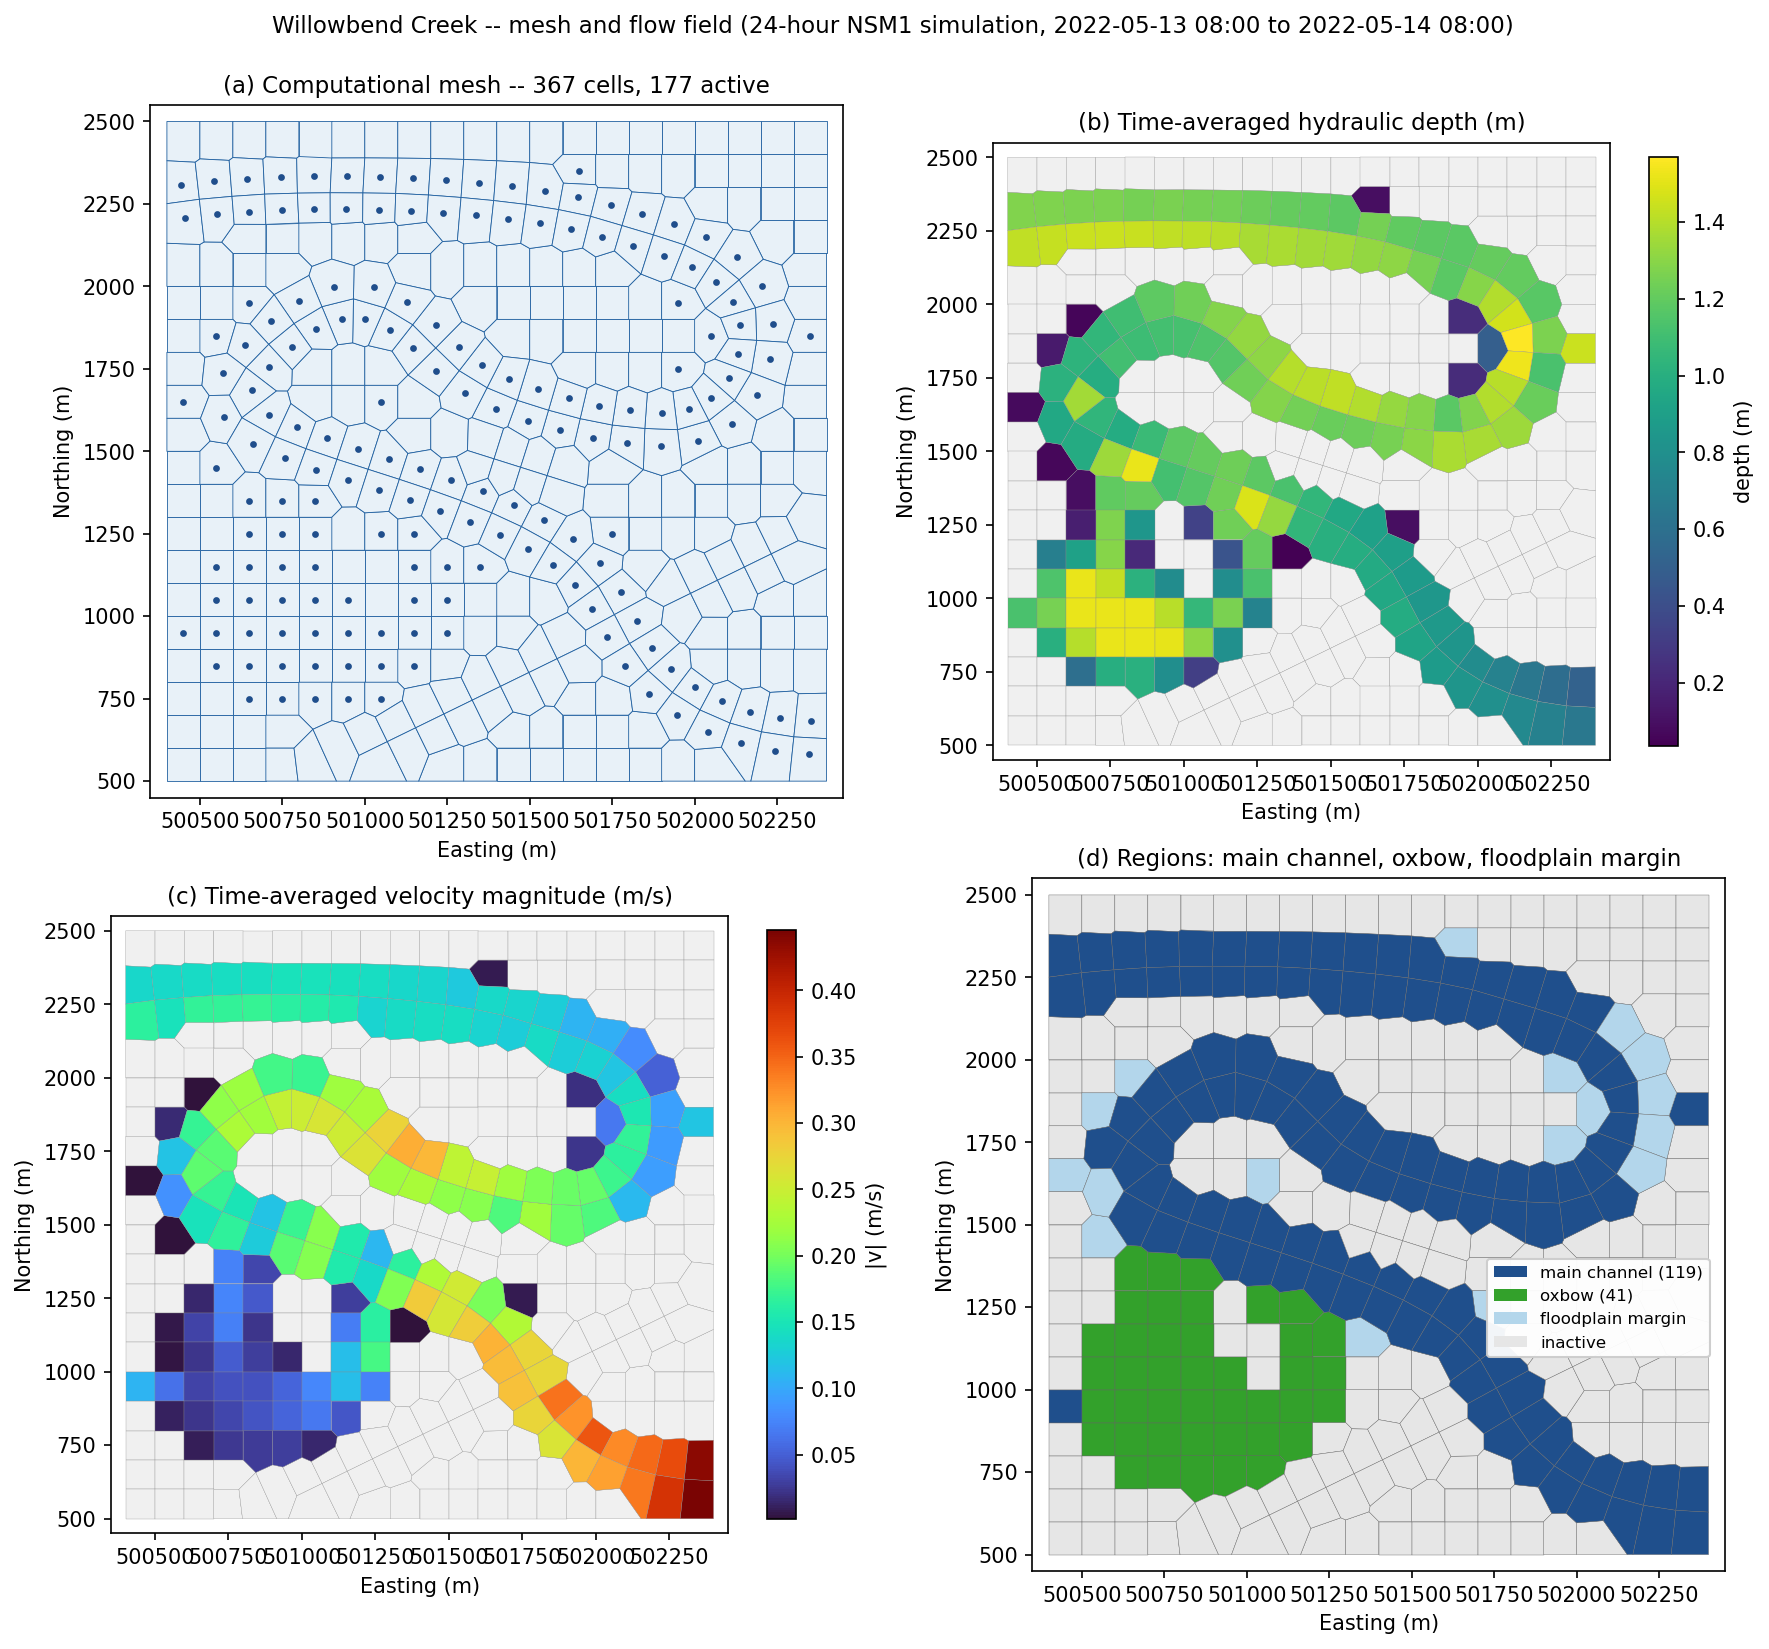

In [4]:
fig_mesh_overview(ds, regions, polys, face_ids)
plt.show()


## 4. Velocity field at a representative time

Velocity-magnitude shading with arrow overlays at midday on the second simulation day.


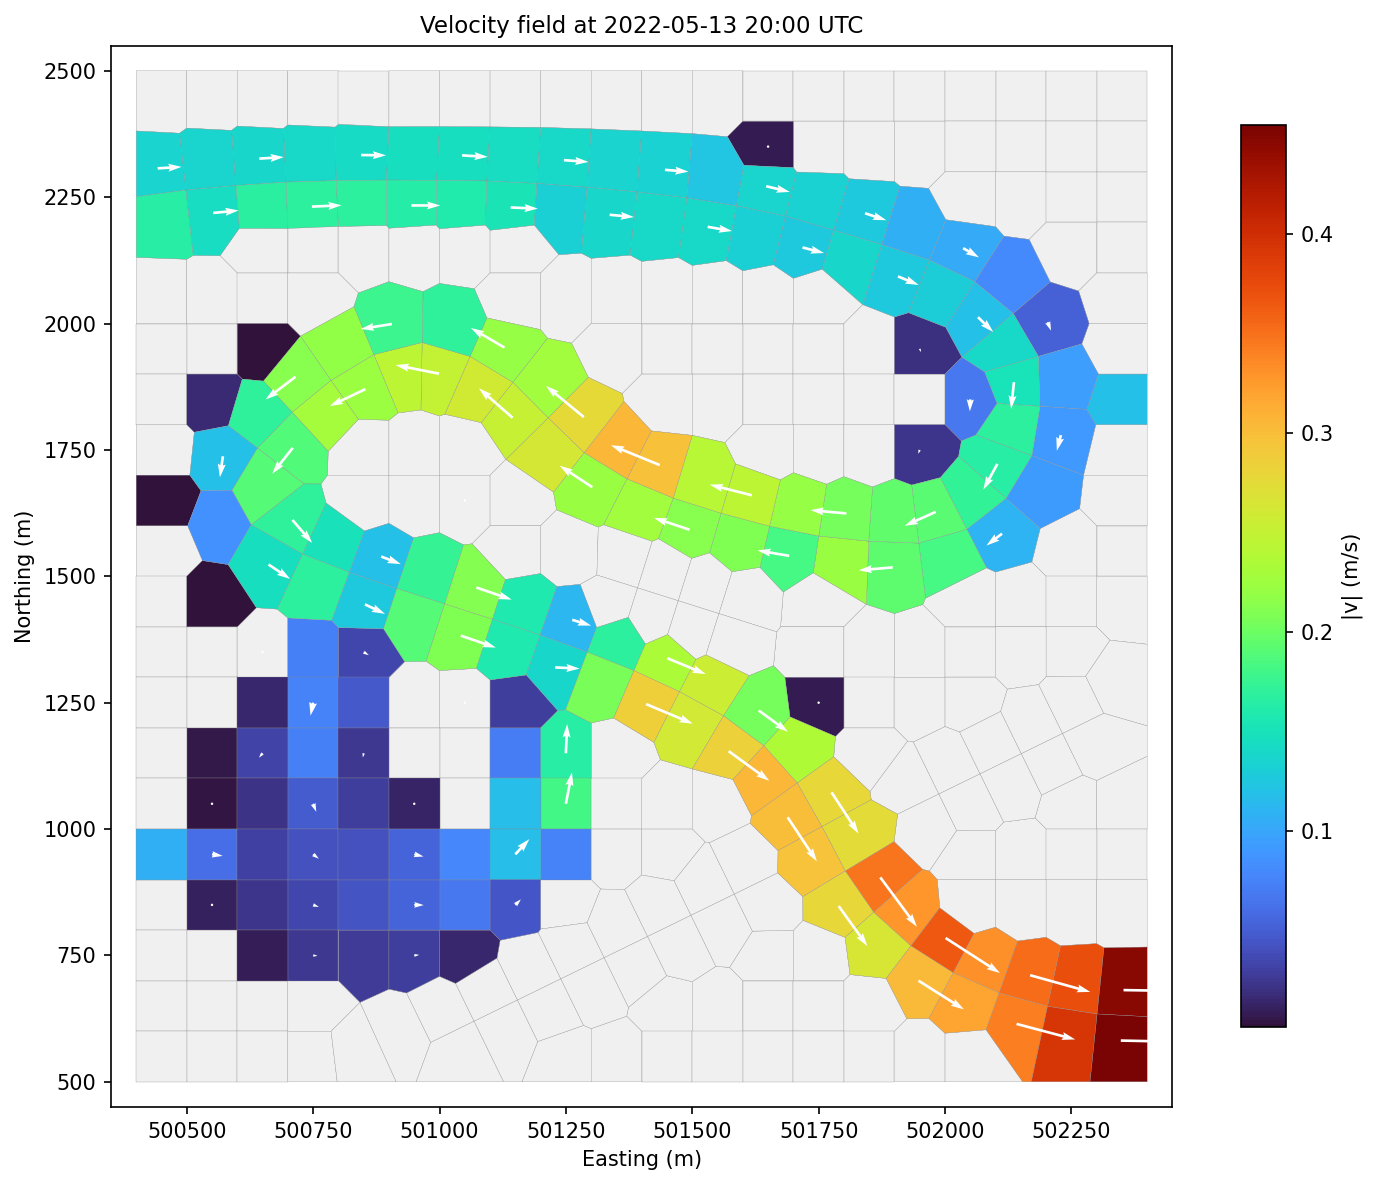

In [5]:
fig_velocity_field(ds, regions, polys, face_ids)
plt.show()


## 5. Spatial nitrogen distribution

Snapshot of NH4 (ammonium), NO3 (nitrate), and OrgN (organic nitrogen) at the spatial-snapshot time. The oxbow region (outlined in dark gray) traps elevated organic nitrogen released by the powerplant inflow; the main channel is dominated by upstream-advected NO3.


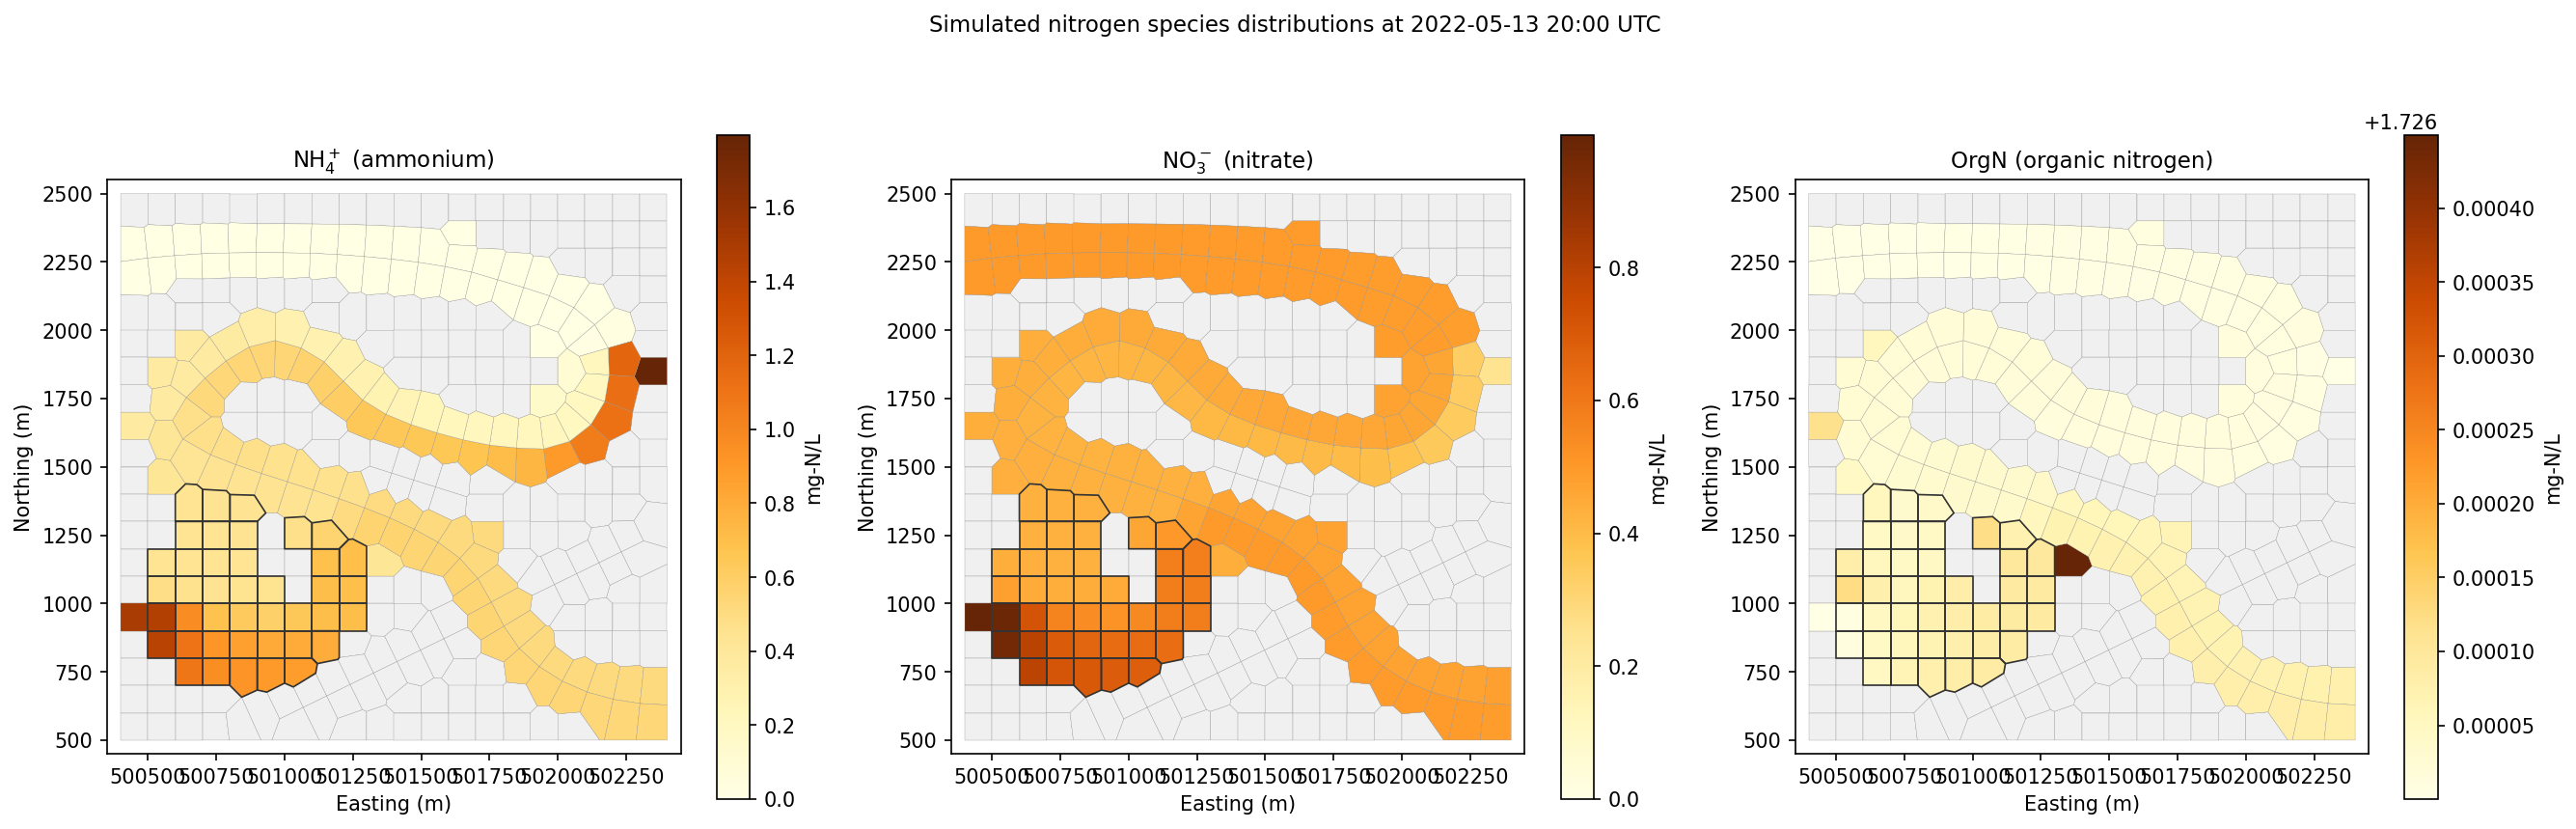

In [6]:
fig_nitrogen_spatial(ds, regions, polys, face_ids, tidx, tstamp)
plt.show()


## 6. Spatial phosphorus distribution

Total inorganic phosphorus (TIP) and organic phosphorus (OrgP). The oxbow concentrates OrgP through the same retention-time mechanism that retains organic nitrogen.


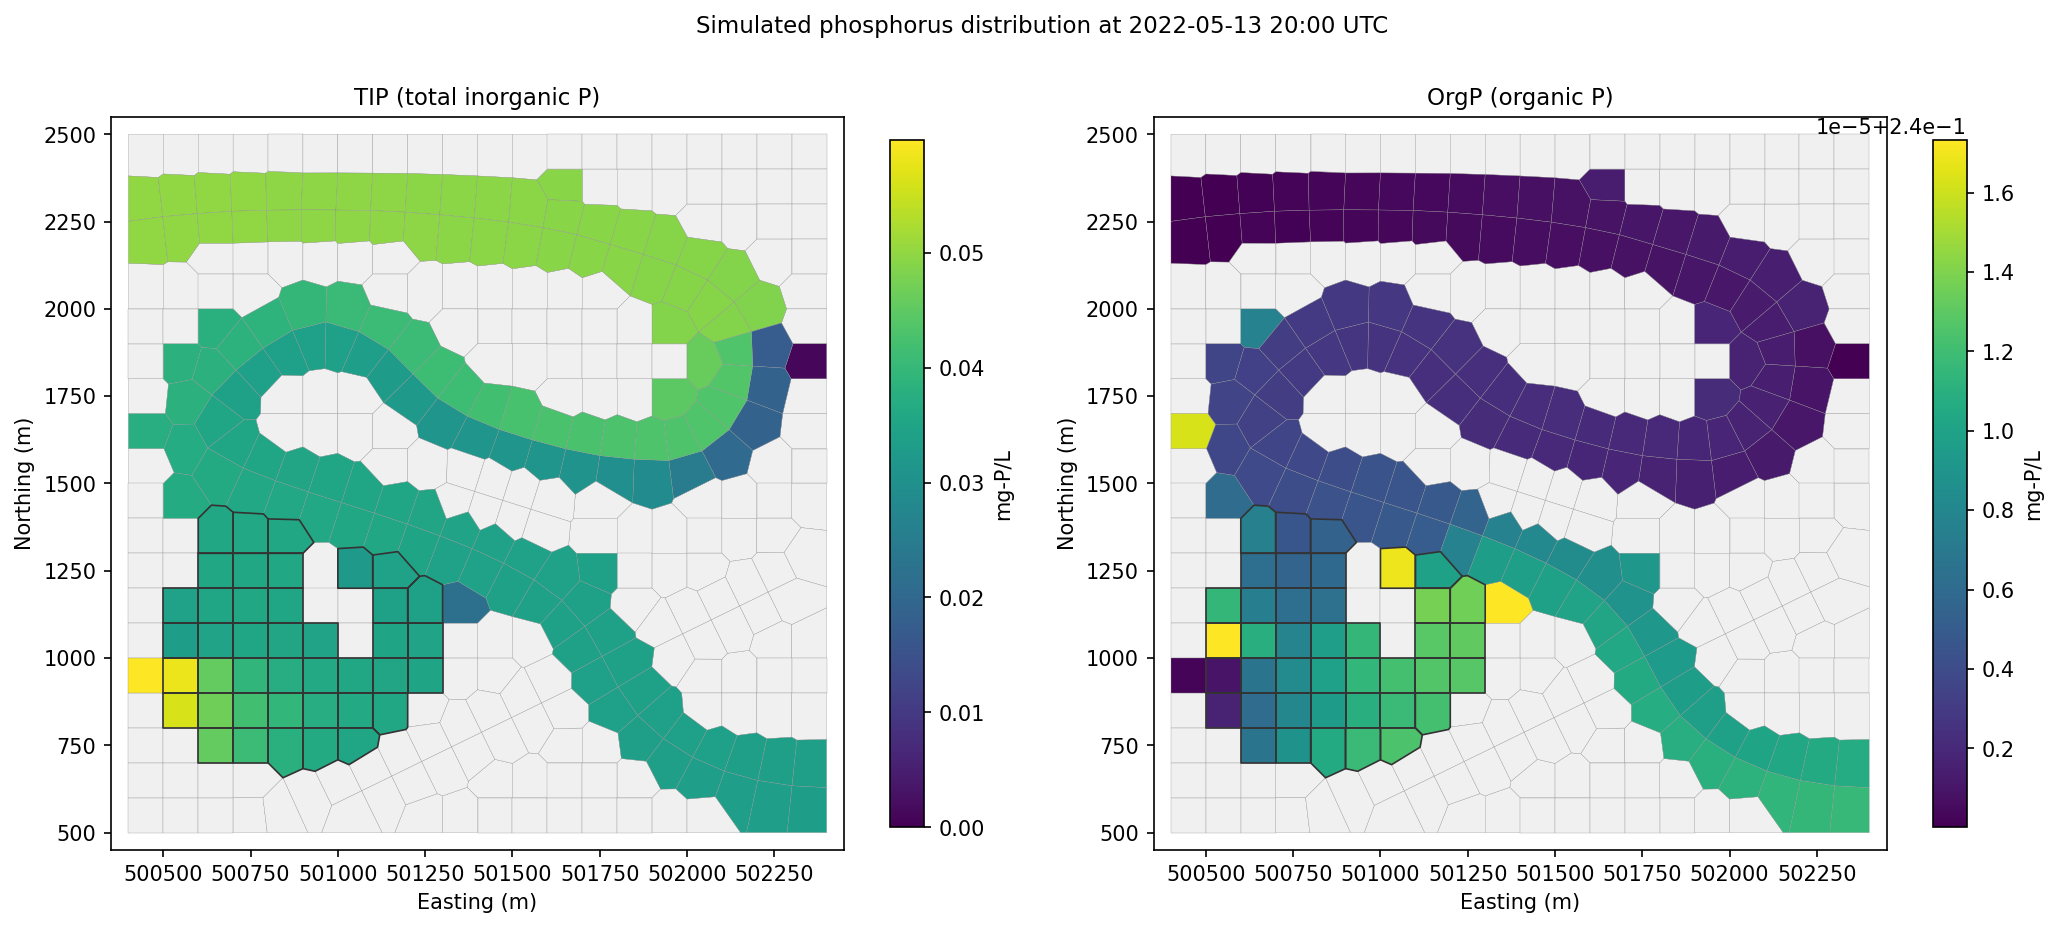

In [7]:
fig_phosphorus_spatial(ds, regions, polys, face_ids, tidx, tstamp)
plt.show()


## 7. Spatial carbon and CBOD distributions

Dissolved organic carbon (DOC), particulate organic carbon (POC), and carbonaceous biochemical oxygen demand (CBOD).


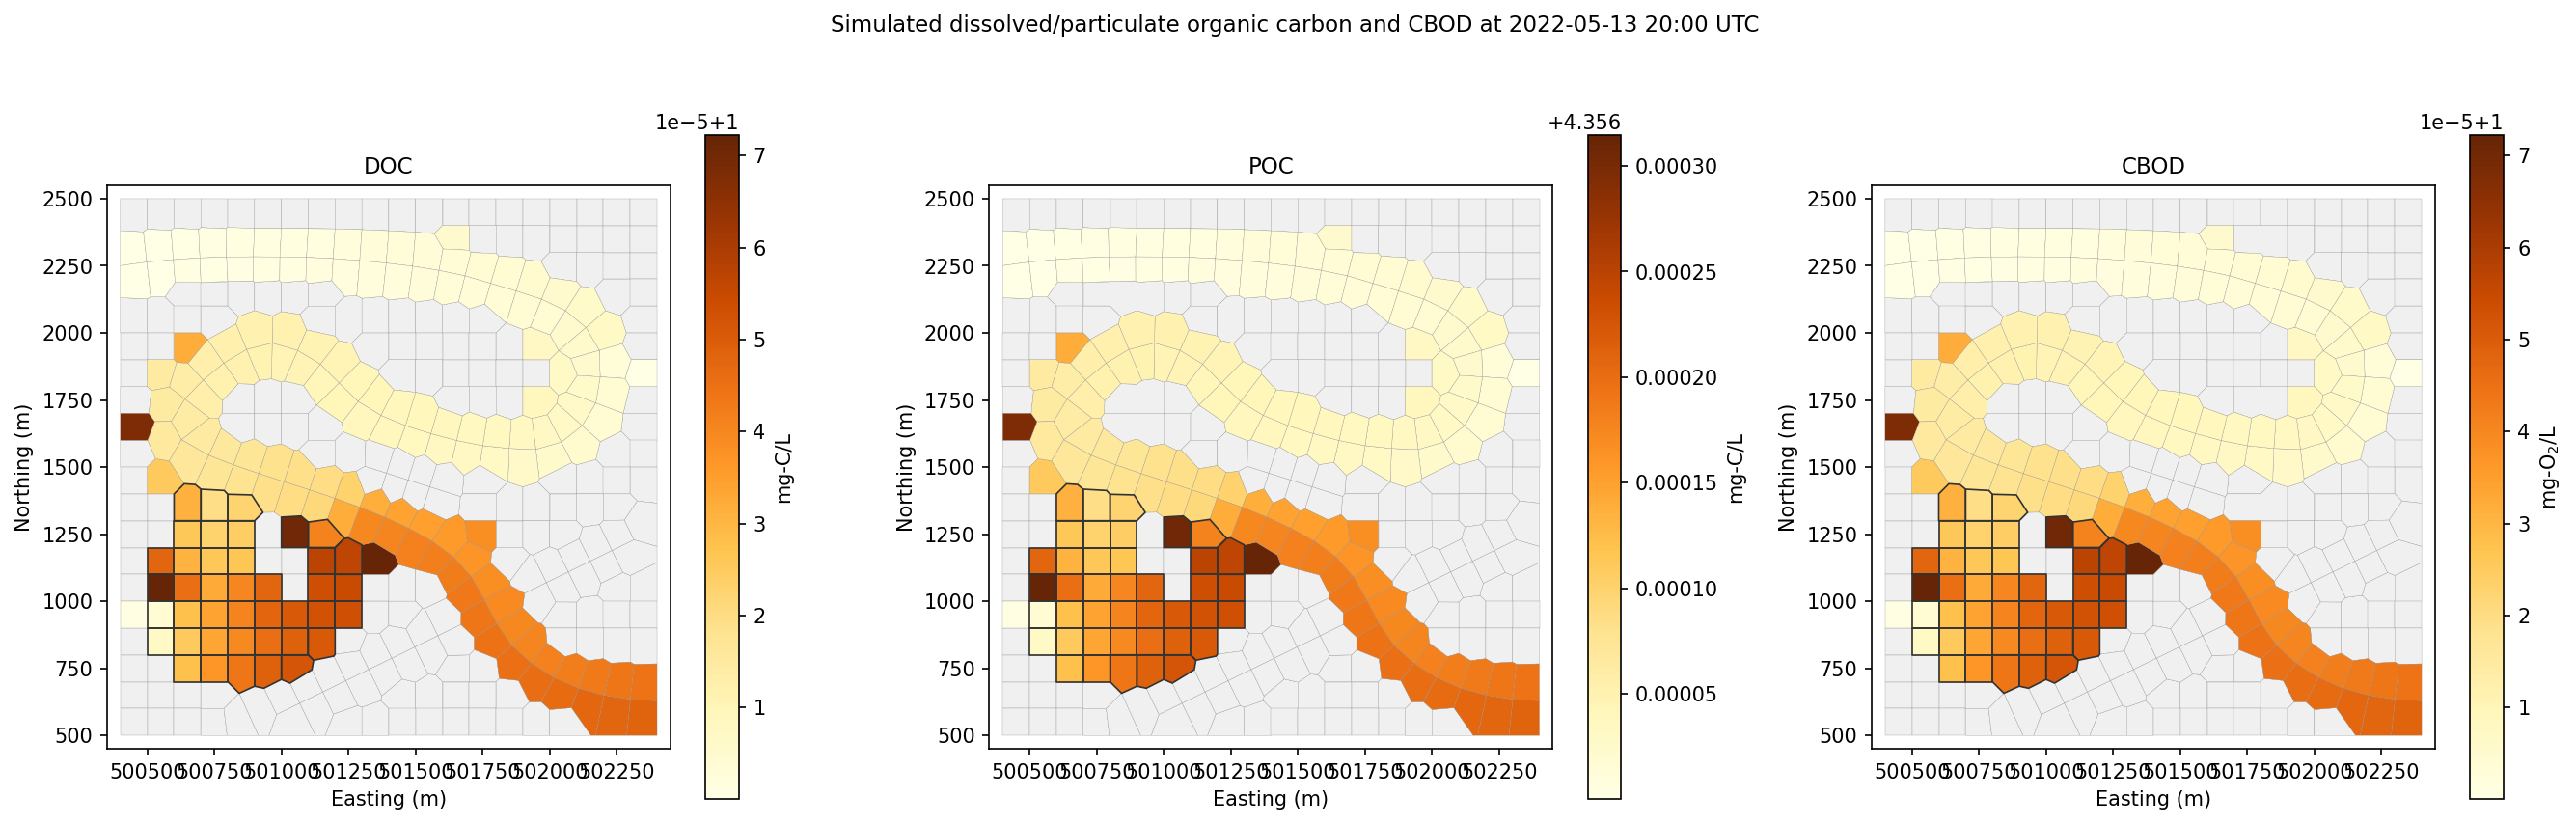

In [8]:
fig_carbon_spatial(ds, regions, polys, face_ids, tidx, tstamp)
plt.show()


## 8. Spatial dissolved oxygen at diurnal extremes

Two-panel snapshot at the within-simulation peak and trough of oxbow-averaged dissolved oxygen. The diurnal swing is largest in the oxbow because of the long residence time and the algal photosynthesis-respiration cycle there.


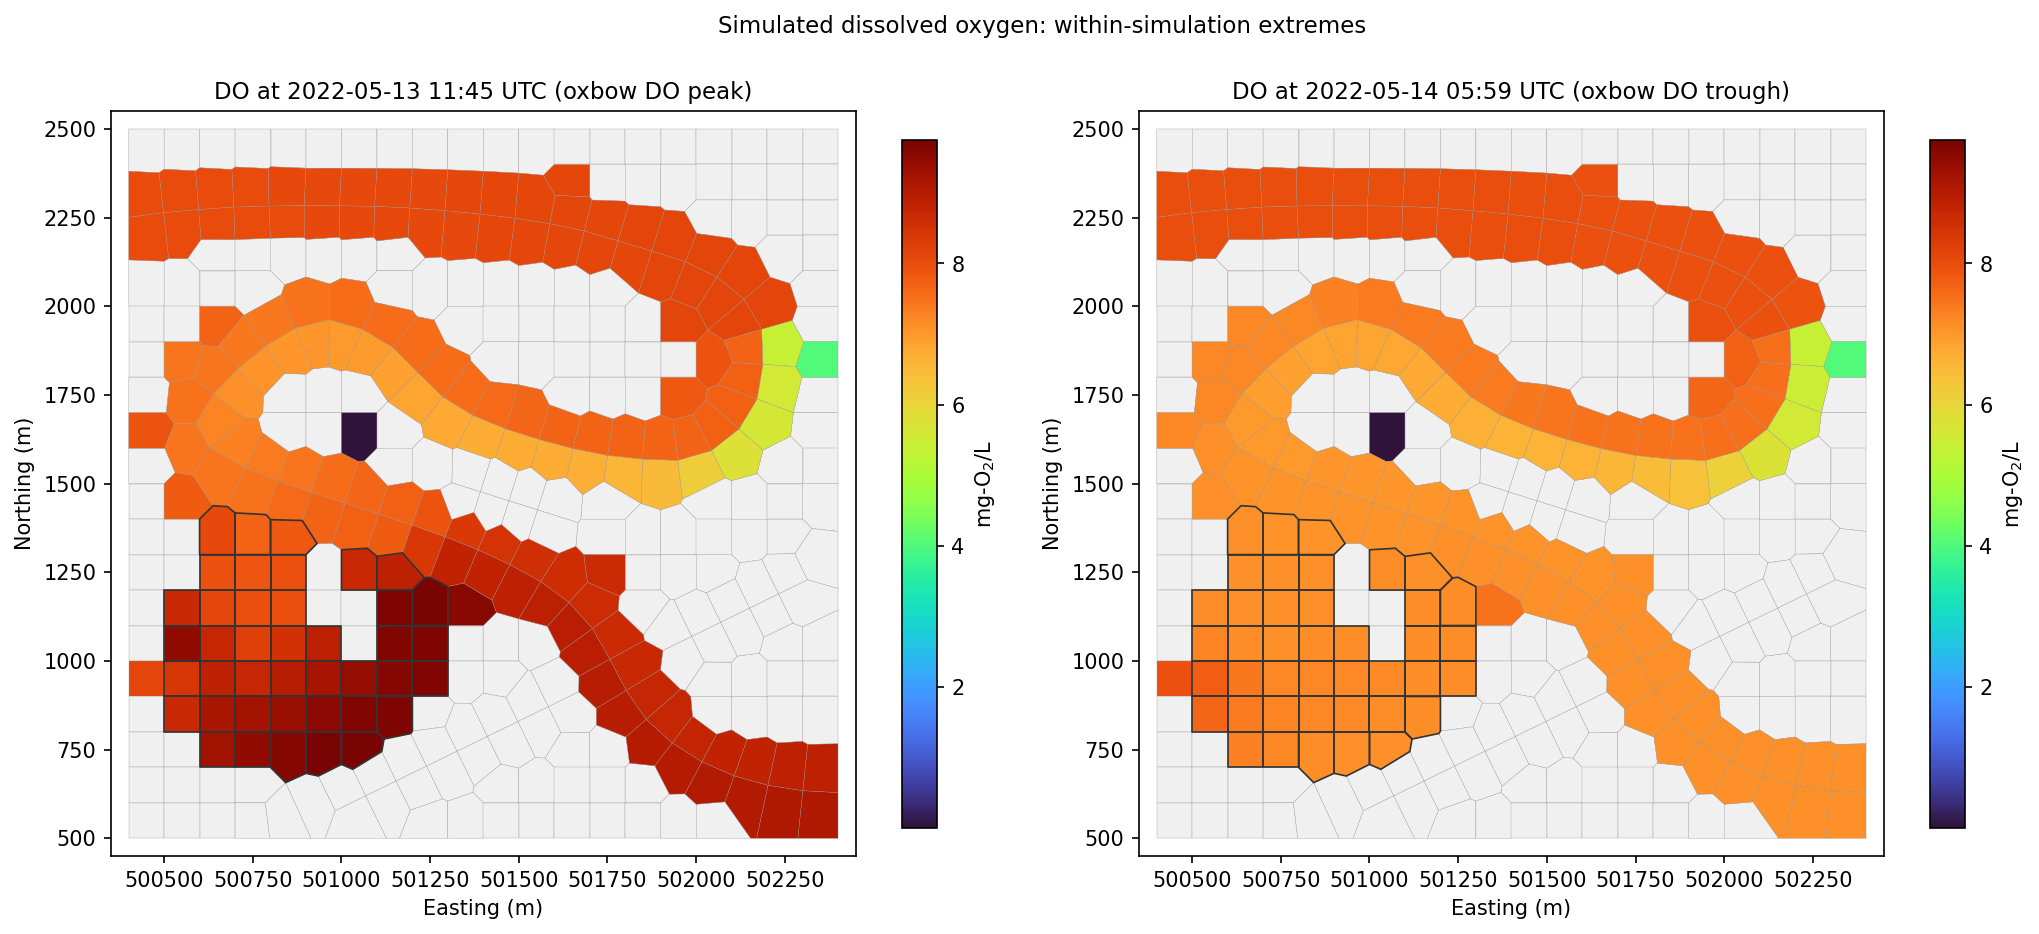

In [9]:
fig_do_spatial(ds, regions, polys, face_ids)
plt.show()


## 9. Spatial algal biomass distribution

Phytoplankton biomass (Ap, in chlorophyll-a equivalents) and benthic algae (Ab, in dry-mass per unit area).


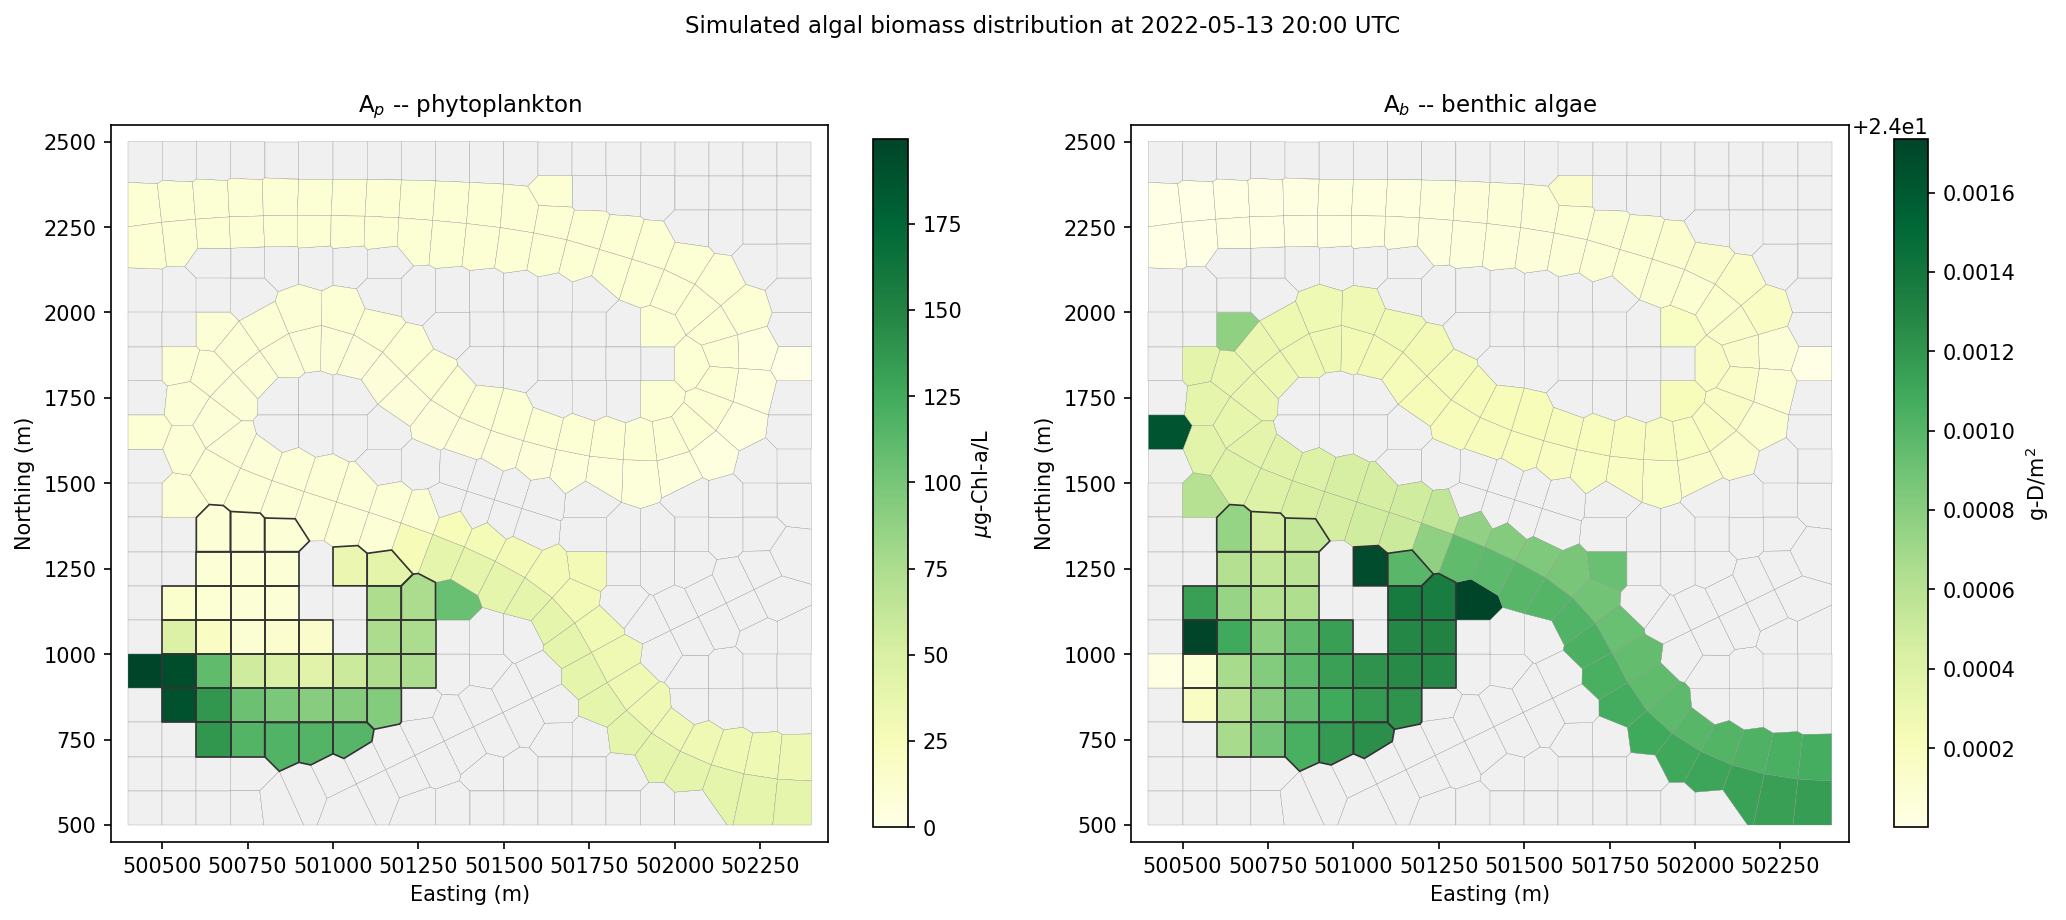

In [10]:
fig_algae_spatial(ds, regions, polys, face_ids, tidx, tstamp)
plt.show()


## 10. Algal nutrient-limitation factors

Diagnostic Michaelis-Menten nutrient-limitation factors derived from the simulated NH4, NO3, and TIP fields. Values close to 1 mean the nutrient is in surplus; values closer to 0 indicate a strong limitation. The third panel maps the limiting nutrient at each cell.


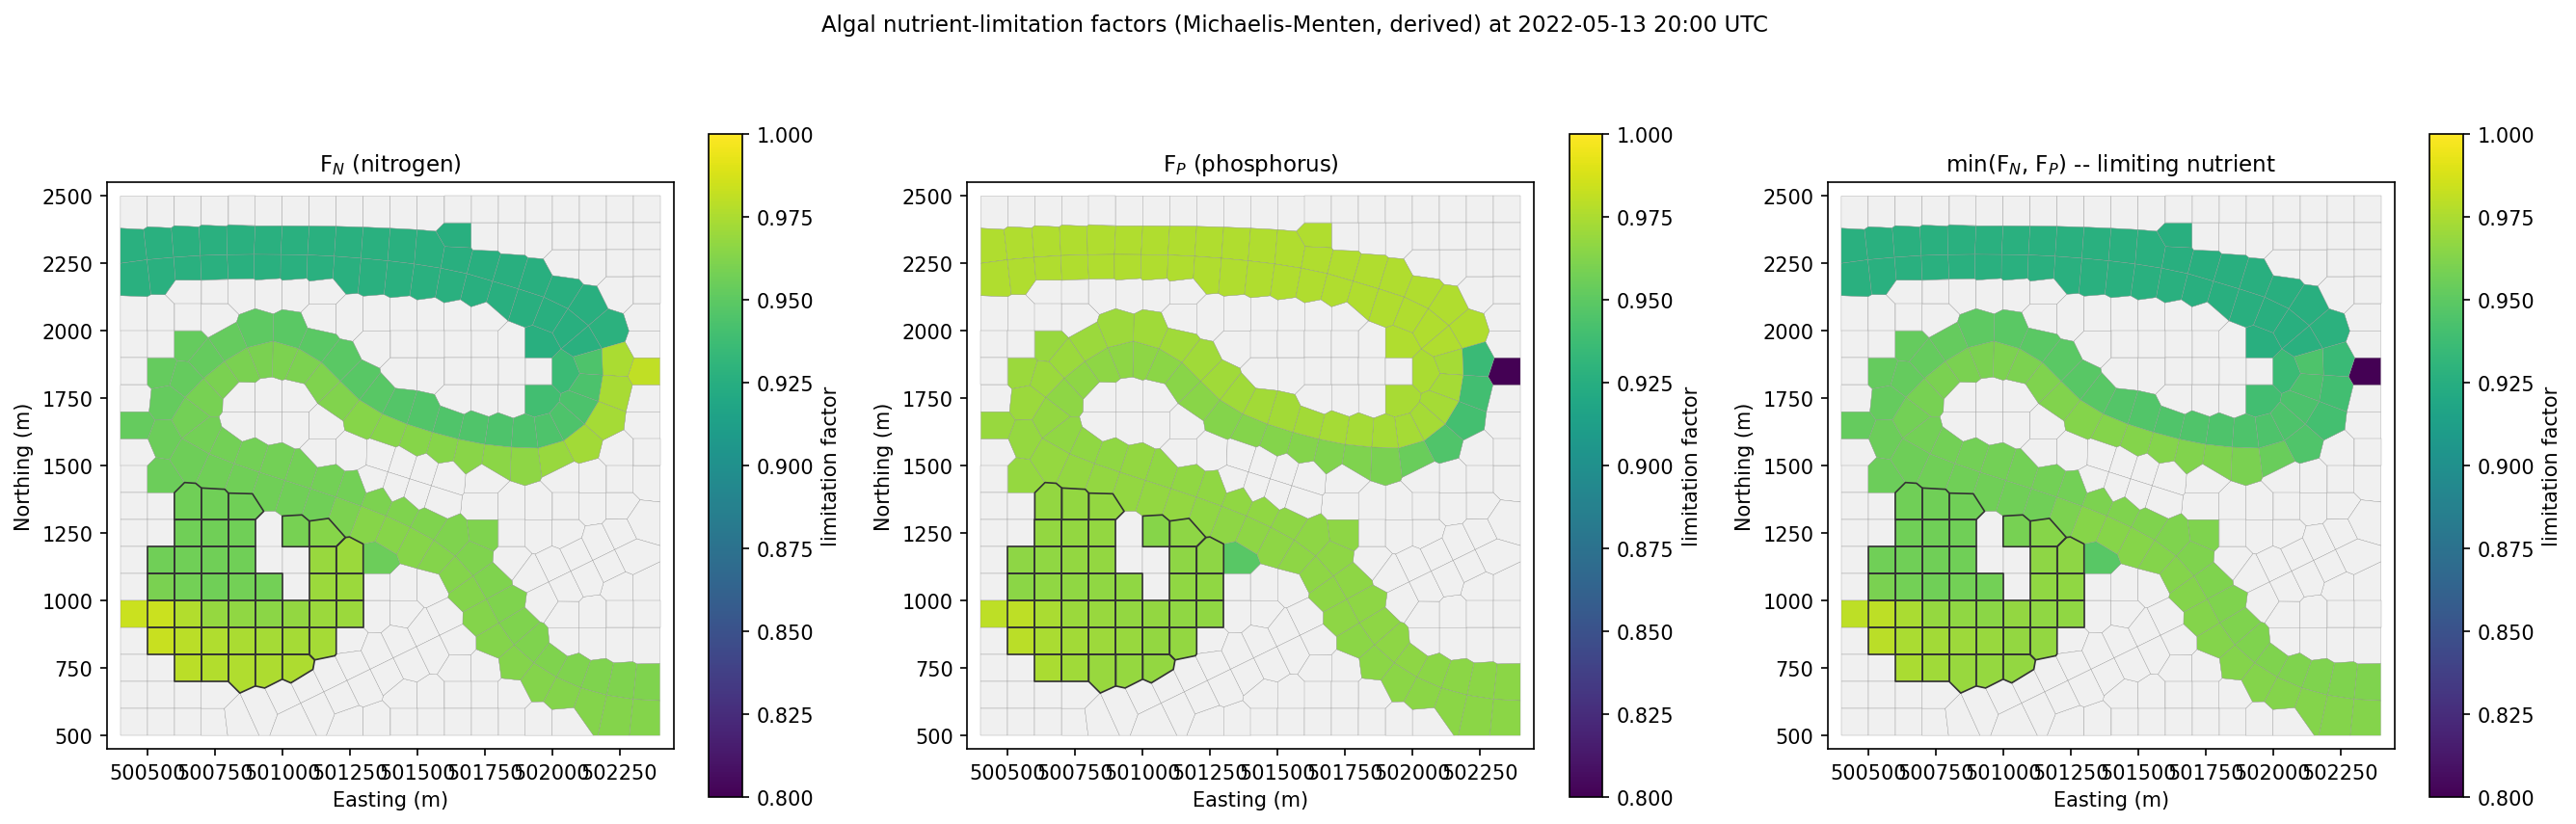

In [11]:
fig_limitation_spatial(ds, regions, polys, face_ids, tidx, tstamp)
plt.show()


## 11. Dissolved oxygen time series

DO at four representative cells (upstream, mid-channel, downstream, oxbow centroid). The oxbow shows the largest diurnal swing.


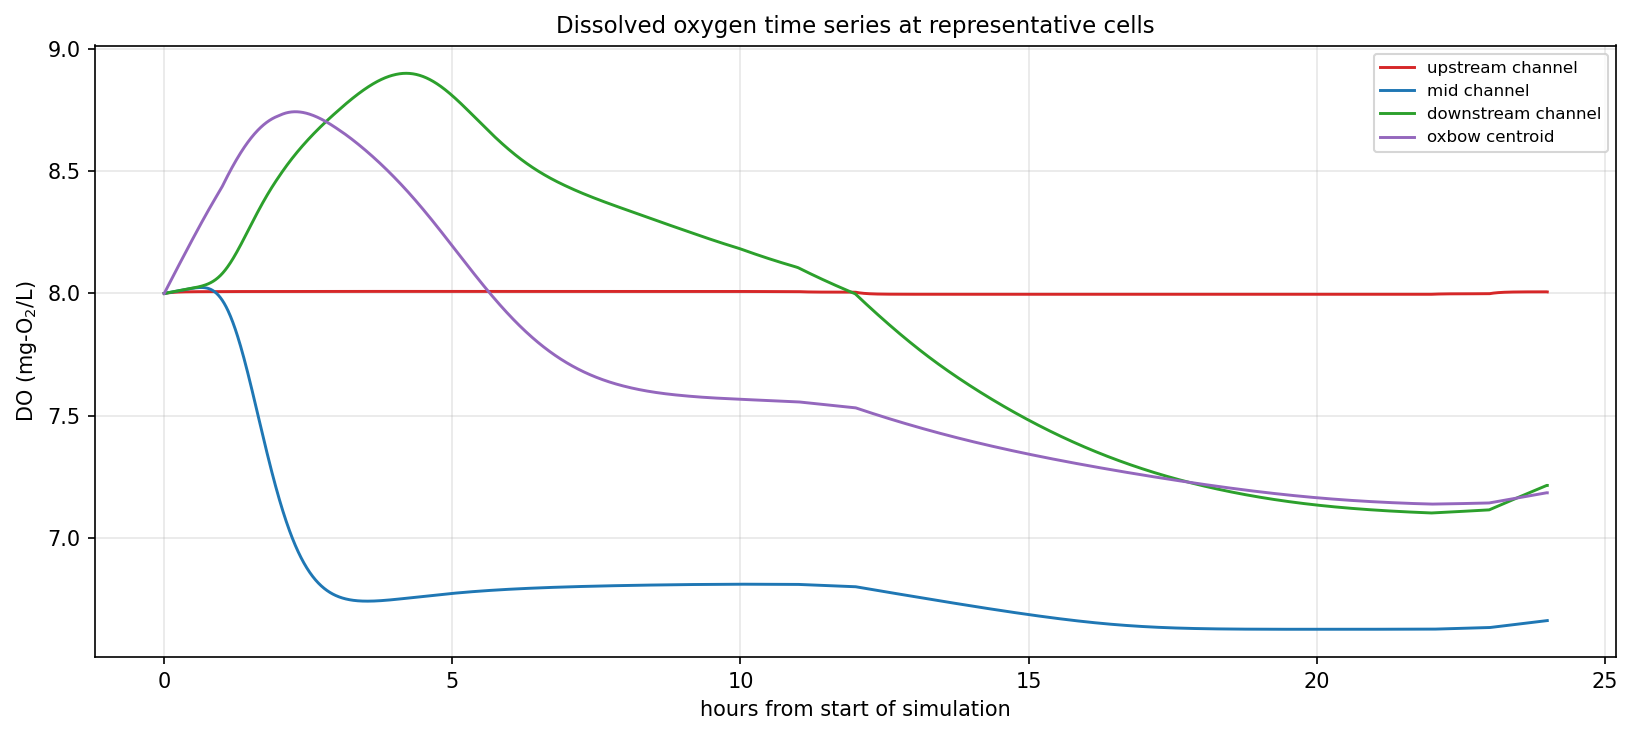

In [12]:
fig_do_timeseries(ds, regions)
plt.show()


## 12. Phytoplankton time series


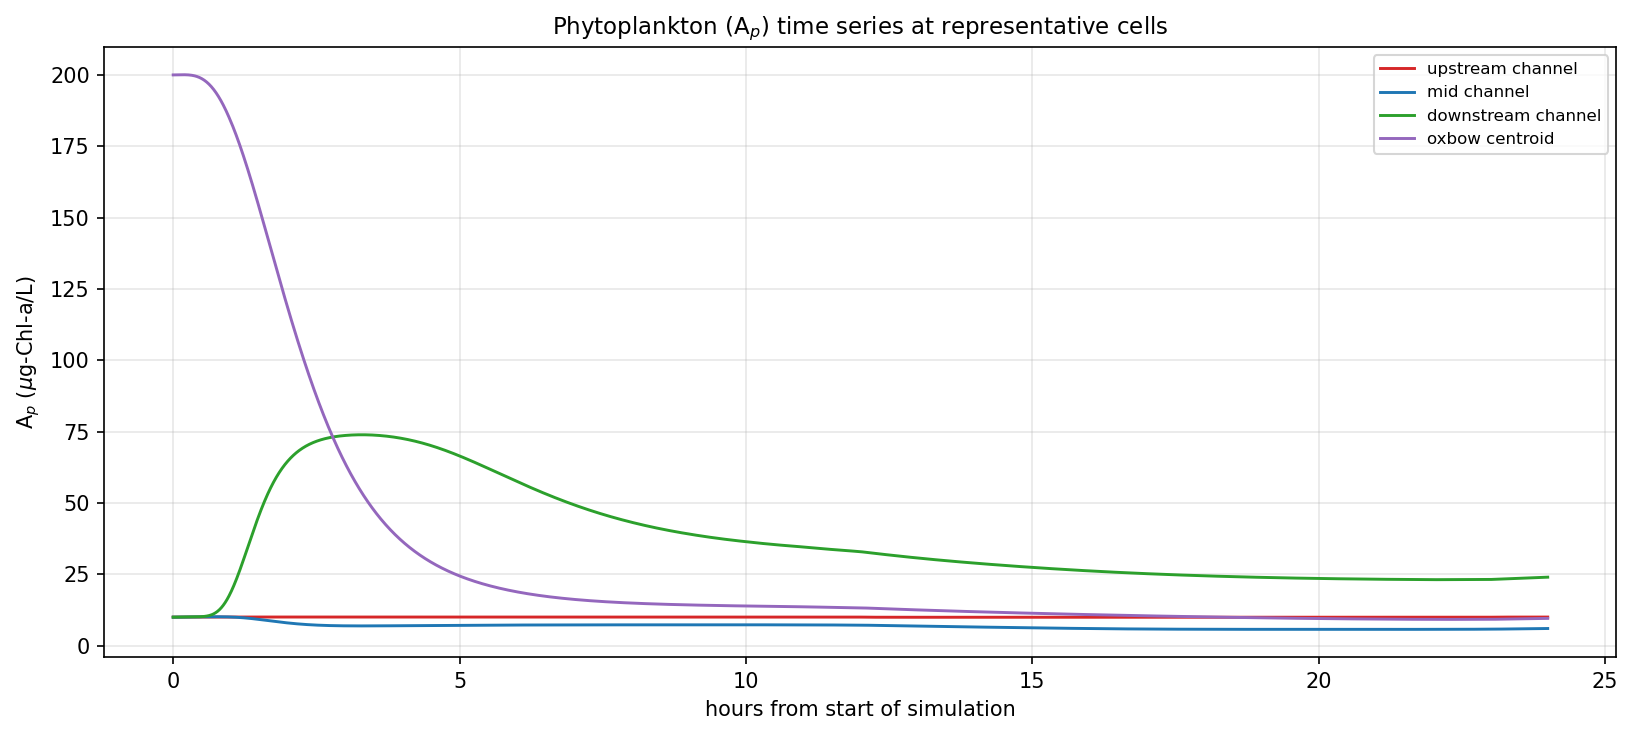

In [13]:
fig_algae_timeseries(ds, regions)
plt.show()


## 13. Mid-channel nutrient time series


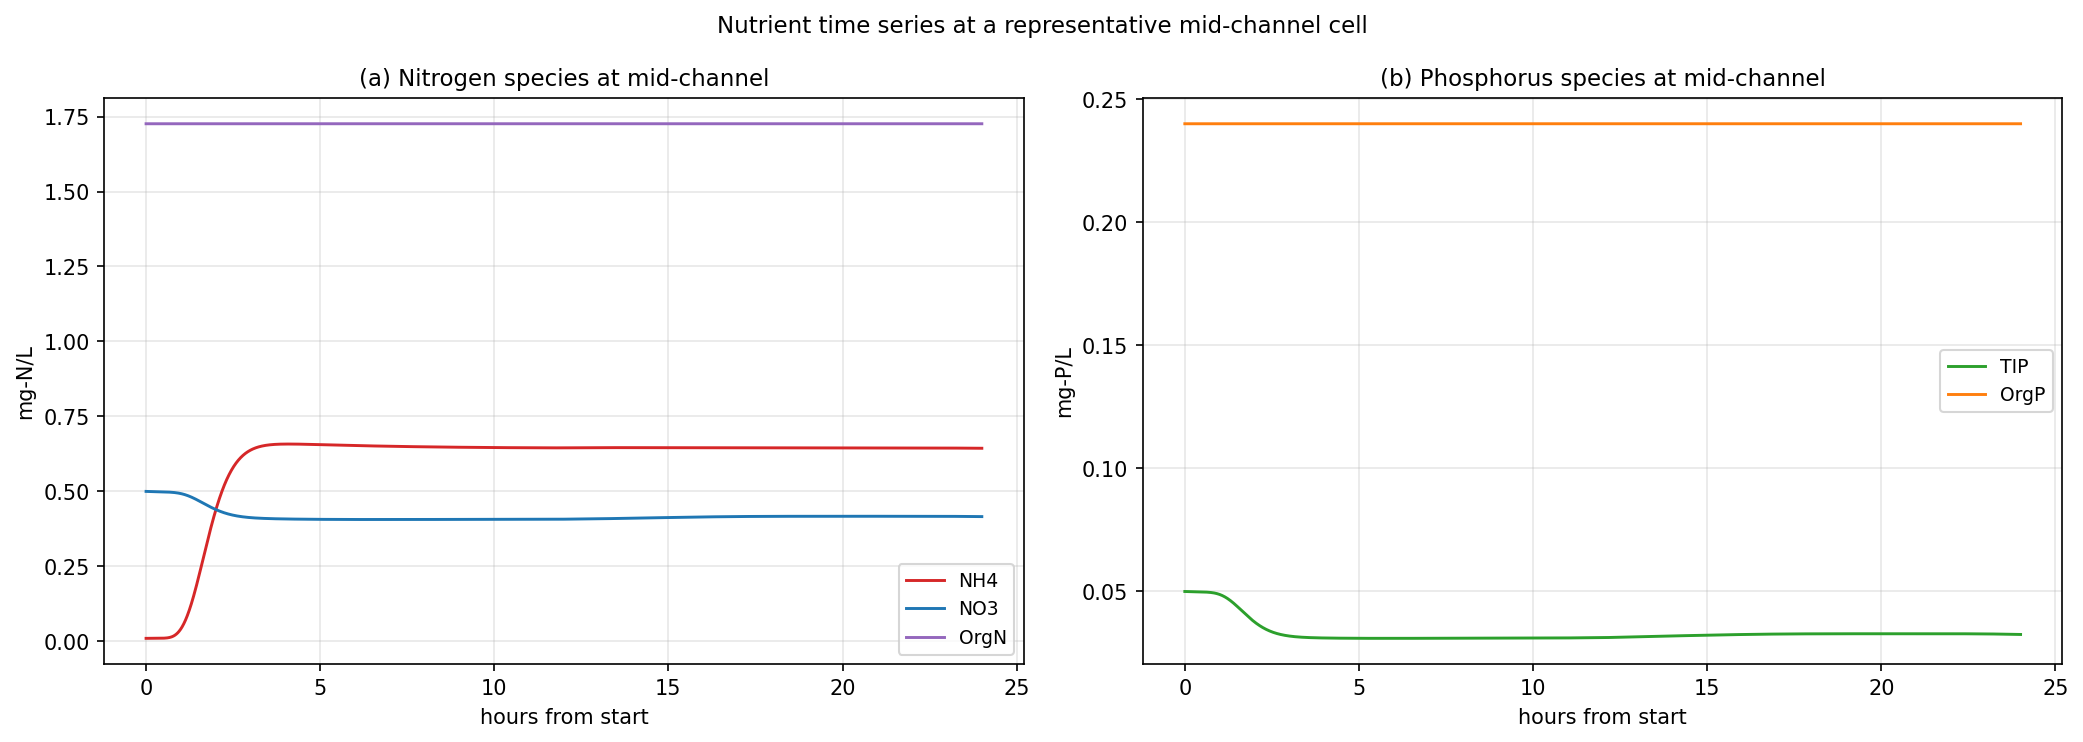

In [14]:
fig_nutrient_timeseries(ds, regions)
plt.show()


## 14. Oxbow-averaged water-quality summary

Three-by-three panel of all major NSM1 state variables averaged over the oxbow region. This is the headline figure for the algae-nutrient-DO coupling story in the technical report.


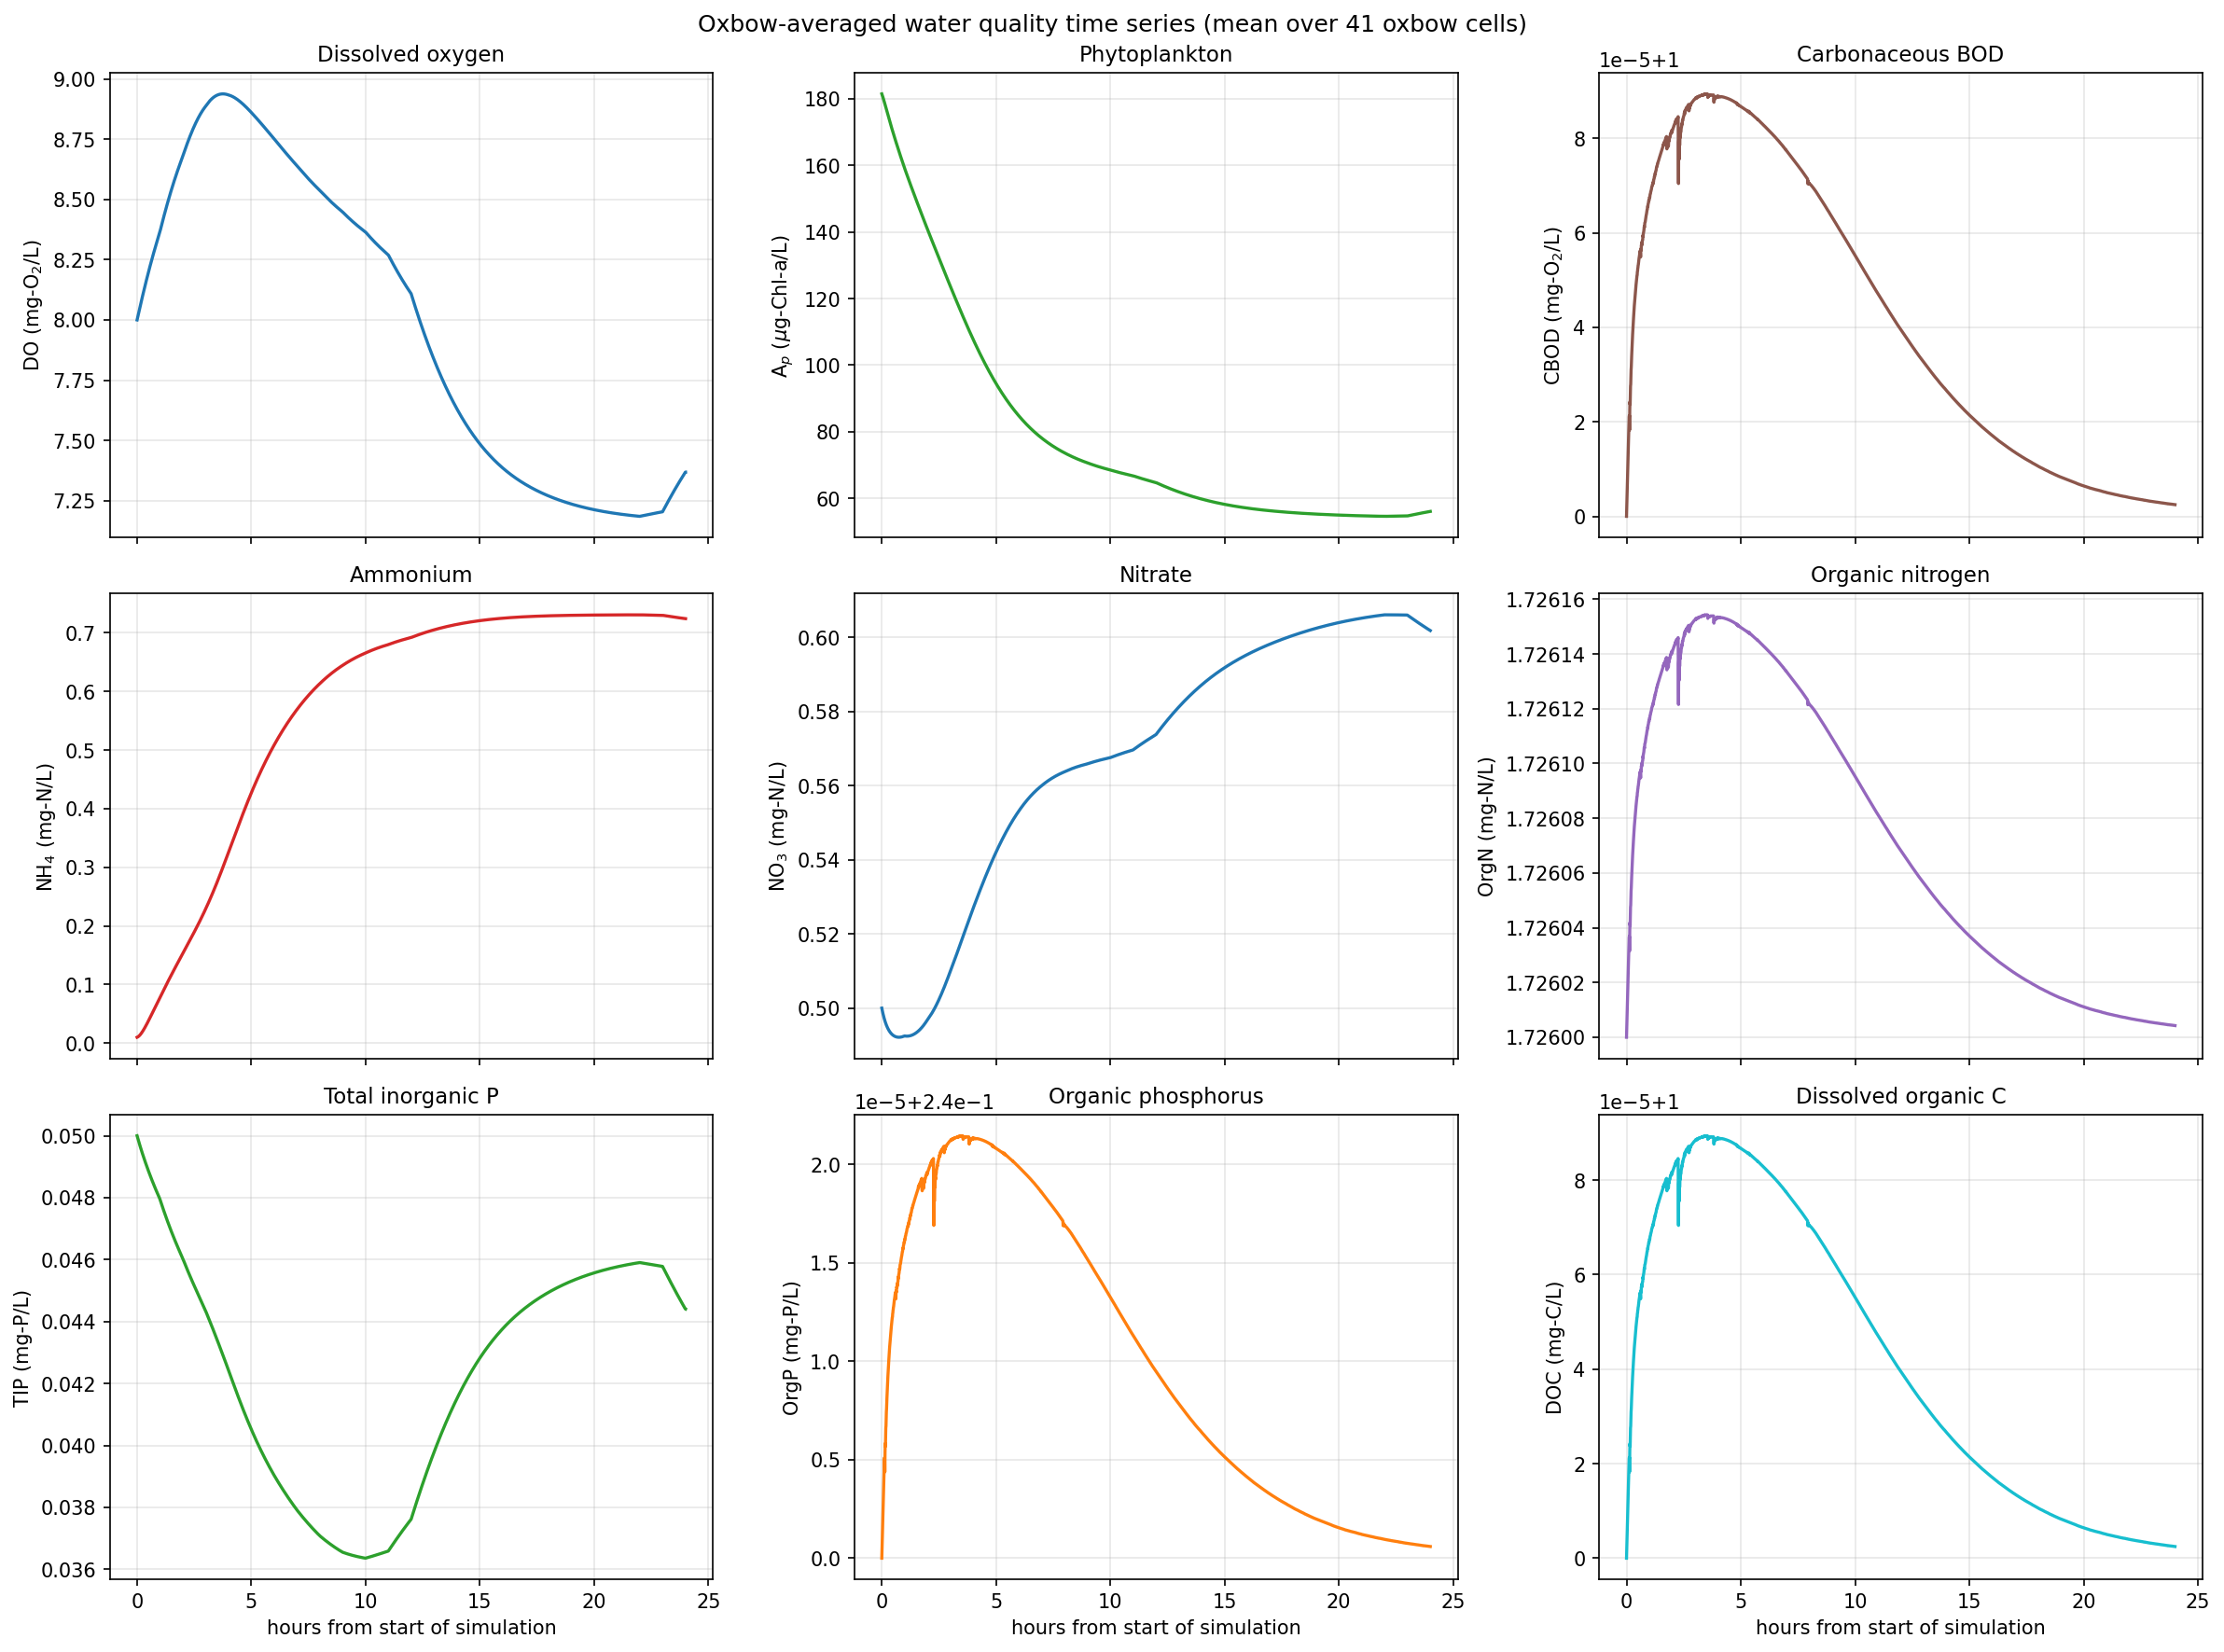

In [15]:
fig_oxbow_averaged_timeseries(ds, regions)
plt.show()


## 15. Algae-DO coupling

(a) Per-cell scatter of mean phytoplankton biomass against DO diurnal amplitude, separated by region. (b) Oxbow-averaged DO and Ap on twin axes.


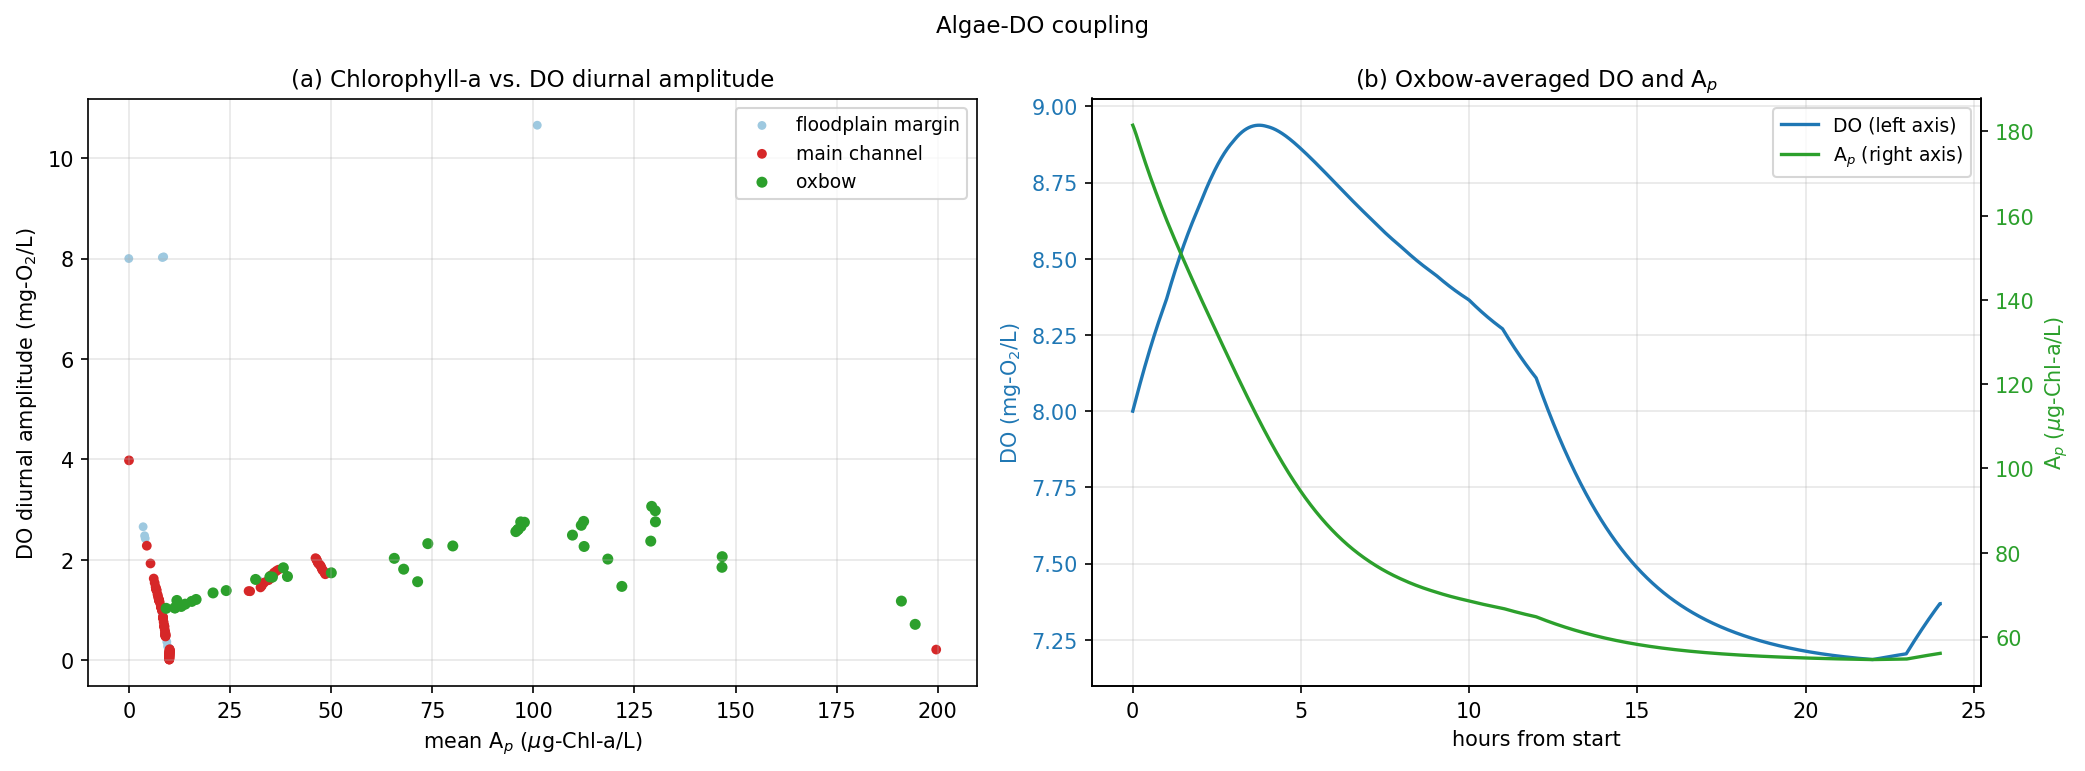

In [16]:
fig_algae_do_coupling(ds, regions)
plt.show()


## Reproducibility

The bundled `nsm1_output.zarr` was produced by running the coupled Riverine + TSM + NSM1 model from the bundled `modules.yml` configuration with the `nsm1` process block enabled. To regenerate it from the bundled inputs:

```python
from pathlib import Path
from clearwater_modules import Model

data_dir = Path('docs/examples/data/willowbend_creek')
model = Model.from_config(data_dir / 'modules.yml')
model.run()
```

The simulation runs from 2022-05-13 08:00 to 2022-05-14 08:00 UTC at a 30-second time step. On a modern laptop the run takes approximately five minutes.

All sixteen NSM1 state variables (NH4, NO3, OrgN, N2, TIP, OrgP, POC, DOC, DIC, DOX, CBOD, Ap, Ab, Alk, POM, PX) are integrated. Boundary conditions for the nutrient species follow the report's Methods section.


## Next steps

- Review the [Theory: Kinetics](../../theory/kinetics.md) page for the Arrhenius temperature correction and Michaelis-Menten formulations used by NSM1.
- Browse the [NSM1 user guide](../../user-guide/nsm1/overview.md) for per-state-variable rate equations, parameter tables, and configuration examples.
- Adapt the bundled `modules.yml` configuration to your own HEC-RAS 2D plan to apply the coupled framework to a new site.
